# Data Visualization — Matplotlib
## The Foundation of Python Visualization
Matplotlib = full control, maximum customization
fig, ax = the two core objects: figure (canvas) and axes (the plot itself)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("financials_clean2.csv")
df['Profit Margin %'] = round((df['Profit'] / df['Sales']) * 100, 2)
print(df.shape)

(688, 29)


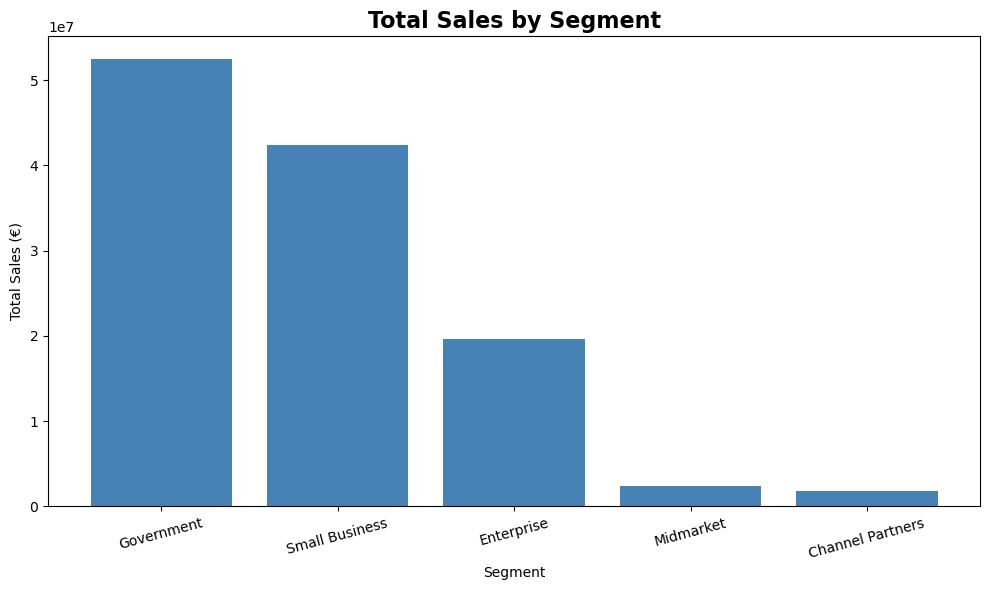

In [2]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(sales_by_segment.index, sales_by_segment.values, color='steelblue')
ax.set_title('Total Sales by Segment', fontsize=16, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Total Sales (€)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

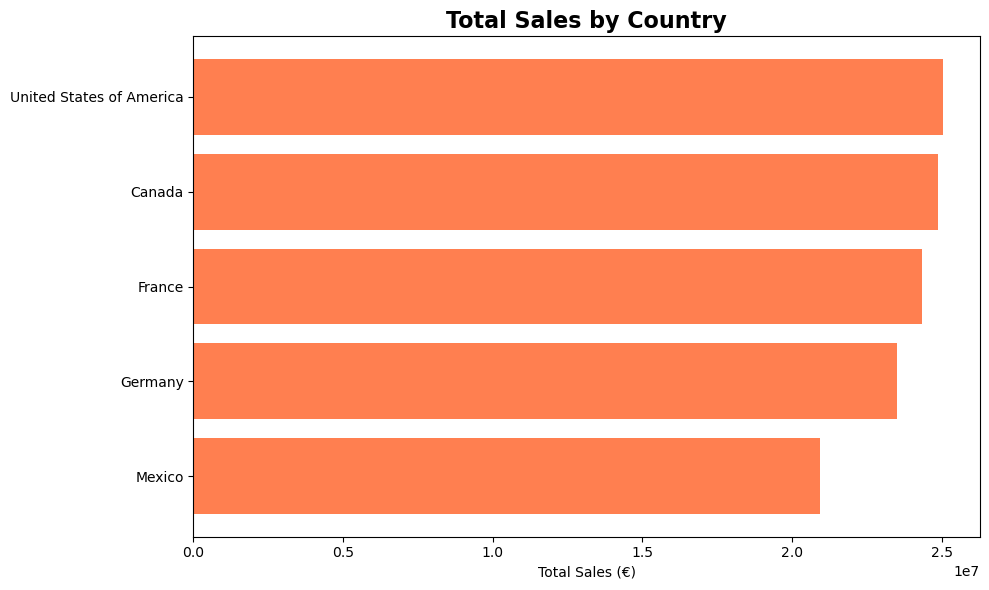

In [3]:
sales_by_country = df.groupby('Country')['Sales'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sales_by_country.index, sales_by_country.values, color='coral')
ax.set_title('Total Sales by Country', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales (€)')
plt.tight_layout()
plt.show()

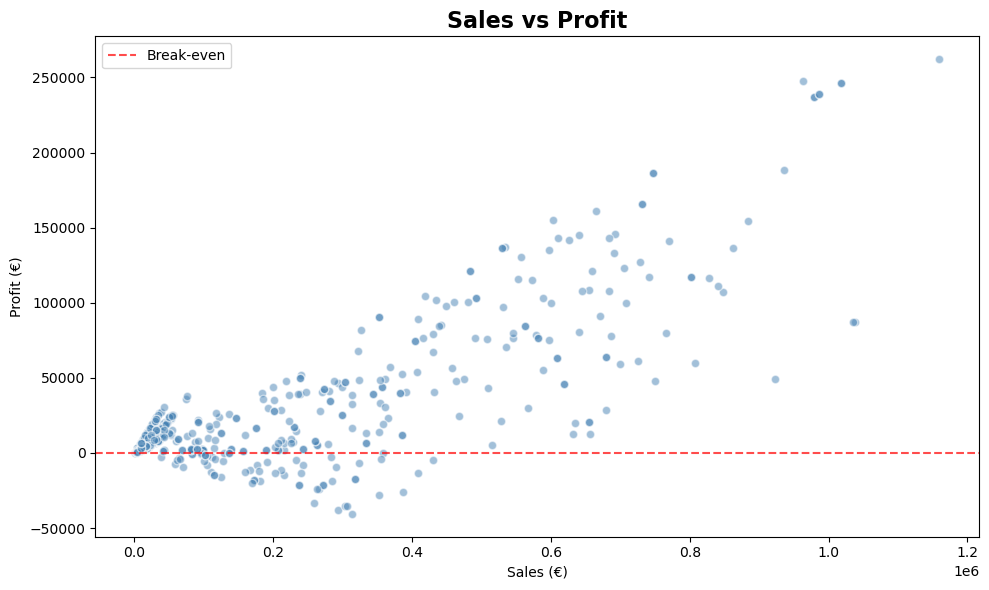

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['Sales'], df['Profit'], alpha=0.5, color='steelblue', edgecolors='white')
ax.set_title('Sales vs Profit', fontsize=16, fontweight='bold')
ax.set_xlabel('Sales (€)')
ax.set_ylabel('Profit (€)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even')
ax.legend()
plt.tight_layout()
plt.show()

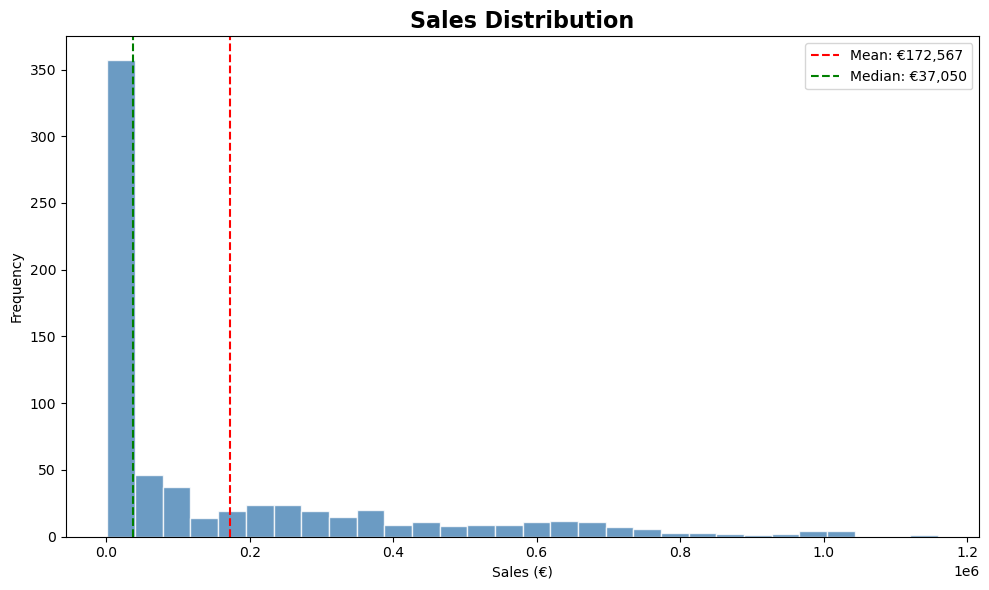

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['Sales'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Sales Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Sales (€)')
ax.set_ylabel('Frequency')
ax.axvline(df['Sales'].mean(), color='red', linestyle='--', label=f"Mean: €{df['Sales'].mean():,.0f}")
ax.axvline(df['Sales'].median(), color='green', linestyle='--', label=f"Median: €{df['Sales'].median():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

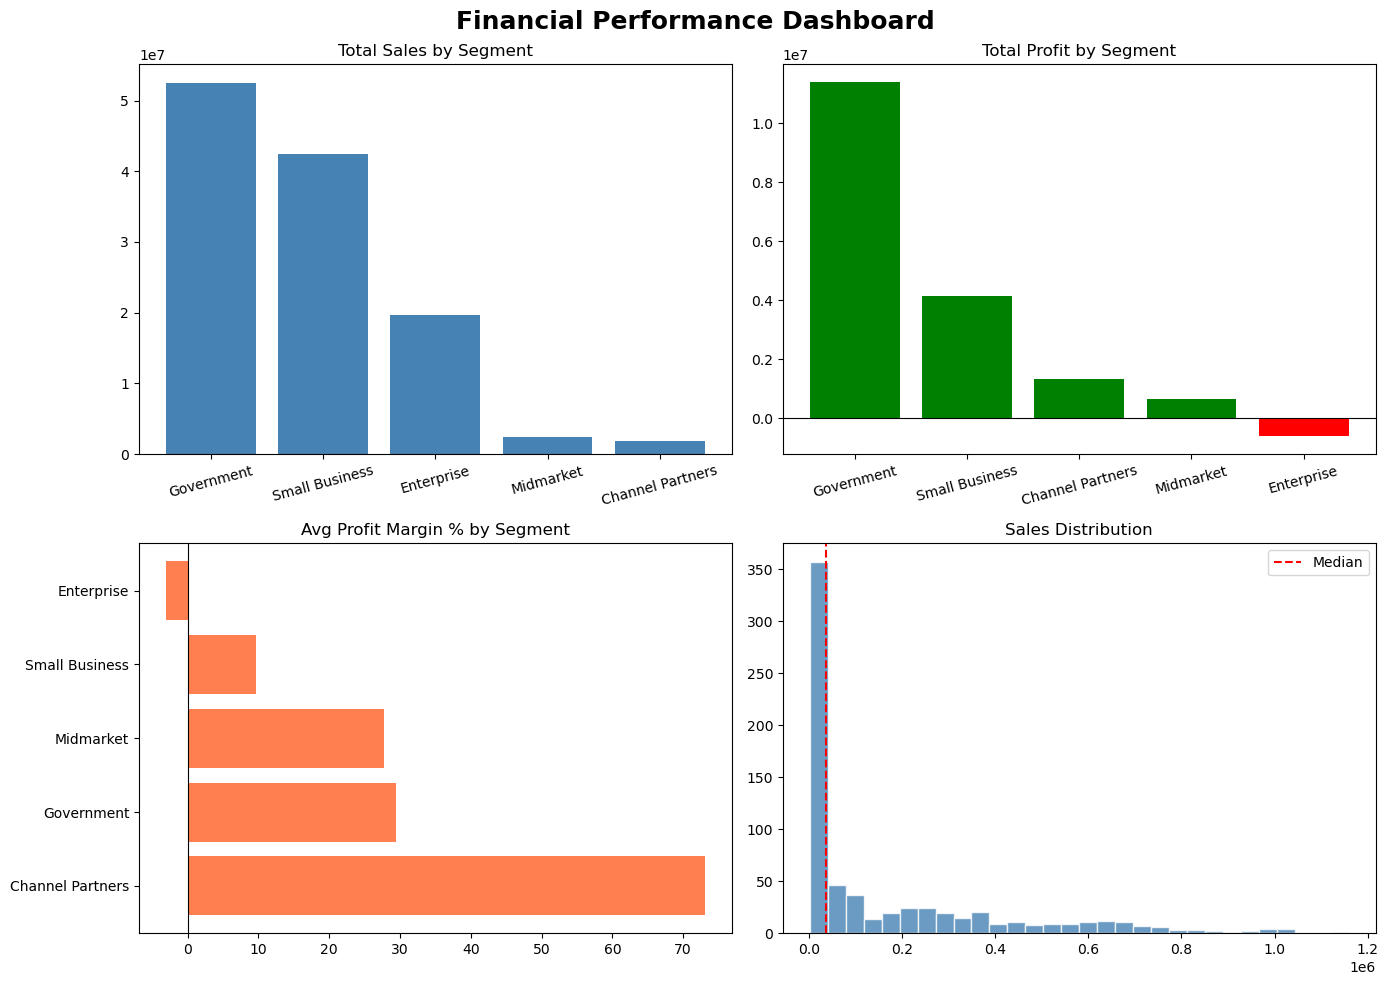

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Financial Performance Dashboard', fontsize=18, fontweight='bold')

# Plot 1 — Sales by Segment
sales_seg = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[0, 0].bar(sales_seg.index, sales_seg.values, color='steelblue')
axes[0, 0].set_title('Total Sales by Segment')
axes[0, 0].tick_params(axis='x', rotation=15)

# Plot 2 — Profit by Segment
profit_seg = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
colors = ['green' if v > 0 else 'red' for v in profit_seg.values]
axes[0, 1].bar(profit_seg.index, profit_seg.values, color=colors)
axes[0, 1].set_title('Total Profit by Segment')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Plot 3 — Avg Margin by Segment
margin_seg = df.groupby('Segment')['Profit Margin %'].mean().sort_values(ascending=False)
axes[1, 0].barh(margin_seg.index, margin_seg.values, color='coral')
axes[1, 0].set_title('Avg Profit Margin % by Segment')
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Plot 4 — Sales distribution
axes[1, 1].hist(df['Sales'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Sales Distribution')
axes[1, 1].axvline(df['Sales'].median(), color='red', linestyle='--', label='Median')
axes[1, 1].legend()

plt.tight_layout()
plt.show()